In [213]:
# import key libraries and kernel settings
import os
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import statsmodels as sm
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols, mixedlm
import time
from datetime import date
import matplotlib.lines as mlines

# updated src file changes are loaded
%load_ext autoreload
%autoreload 2

sys.path.append(os.path.abspath(".."))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [299]:
# import a single target x water speed solution dataset
df_wide = pd.read_csv("C:/Users/jacob/water_current_MA/data/solution_space/errors_-3_L60.csv")
speeds = df_wide.loc[:, 'Unnamed: 0'].values

# replace name of first index column to something more informative
df_wide.rename(columns={'Unnamed: 0': 'speed'}, inplace=True)

# convert to long format
df_long = df_wide.melt(
    id_vars=['speed'],
    var_name = 'angle',
    value_name = 'error_m'
)
df_long.head(50)

# ensure float
df_long['angle'] = pd.to_numeric(df_long['angle'])


# make boolean variable that labels which launch parameter combinations result in errors below 10.0 cm
df_long['is_hit'] = df_long['error_m'] < 0.10

# make df with ONLY hits since we are comparing the participant's executed launches to the NEAREST valid launch solutions
df_hits = df_long[df_long['is_hit'] == True].copy()


pandas.core.series.Series

In [345]:
# import in subset df_L60_3_T1
df_participant = pd.read_csv("C:/Users/jacob/water_current_MA/data/solution_space/df_L60_3_T1.csv")
df_participant.columns

speeds_std = df_participant['launch_Speed'].std()
theta_std = df_participant['launch_angle'].std()


In [375]:

# make hit and real speeds into np.array
hit_speeds = df_hits['speed'].values
real_speeds = df_participant['launch_Speed'].values

# make hit and real angles into np.array
hit_thetas = df_hits['angle'].values
real_thetas = df_participant['launch_angle'].values

# broadcast and find differences, then normalize by variability of each parameter
speed_diffs = (real_speeds[:, np.newaxis] - hit_speeds[np.newaxis, :]) / speeds_std
theta_diffs = (real_thetas[:, np.newaxis] - hit_thetas[np.newaxis, :]) / theta_std

d = np.sqrt((speed_diffs**2) + (theta_diffs**2))
min_d = np.min(d, axis=1)




numpy.ndarray

In [365]:
# now take min_d array and make it a column in df_participant for plotting
df_participant['min_d'] = min_d
df_participant

,Unnamed: 0,experiment,ppid_full,speed_label,target_x_label,target_position_x_cm,target_position_z_cm,trial_num,phase,phase_trial_num,...,is_outlier,launch_deviation_mean,launch_deviation_median,flip_min_distance_xPCA_mean,flip_min_distance_xPCA_median,launch_deviation_mean_bc,launch_deviation_median_bc,flip_min_distance_xPCA_mean_bc,flip_min_distance_xPCA_median_bc,min_d
0,20303,S1_3.0M-projectile_experiment 1,1_neg3,-3.0,L60,-60.0,140.0,53,training_1,1,...,False,0.153491,1.766991,-6.070105,-10.584746,2.752700,1.13920,67.908700,72.423341,2.141549
1,20304,S1_3.0M-projectile_experiment 1,1_neg3,-3.0,L60,-60.0,140.0,55,training_1,3,...,False,0.153491,1.766991,-6.070105,-10.584746,68.679630,67.06613,18.885337,23.399978,0.235184
2,20307,S1_3.0M-projectile_experiment 1,1_neg3,-3.0,L60,-60.0,140.0,58,training_1,6,...,False,0.153491,1.766991,-6.070105,-10.584746,76.740860,75.12736,-3.164352,1.350289,0.025923
3,20309,S1_3.0M-projectile_experiment 1,1_neg3,-3.0,L60,-60.0,140.0,60,training_1,8,...,False,0.153491,1.766991,-6.070105,-10.584746,63.567300,61.95380,-24.497774,-19.983133,0.509096
4,20310,S1_3.0M-projectile_experiment 1,1_neg3,-3.0,L60,-60.0,140.0,61,training_1,9,...,False,0.153491,1.766991,-6.070105,-10.584746,71.018780,69.40528,-17.120169,-12.605528,0.231289
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1480,40011,S1_3.0M-projectile_experiment 1,p048_neg3,-3.0,L60,-60.0,140.0,193,training_1,141,...,False,-1.594872,-2.112009,0.297211,3.268425,38.031663,38.54880,7.786019,4.814805,0.123373
1481,40014,S1_3.0M-projectile_experiment 1,p048_neg3,-3.0,L60,-60.0,140.0,196,training_1,144,...,False,-1.594872,-2.112009,0.297211,3.268425,47.705363,48.22250,-11.958068,-14.929283,0.023386
1482,40015,S1_3.0M-projectile_experiment 1,p048_neg3,-3.0,L60,-60.0,140.0,197,training_1,145,...,False,-1.594872,-2.112009,0.297211,3.268425,38.688183,39.20532,-16.187316,-19.158530,0.053744
1483,40017,S1_3.0M-projectile_experiment 1,p048_neg3,-3.0,L60,-60.0,140.0,199,training_1,147,...,False,-1.594872,-2.112009,0.297211,3.268425,38.880773,39.39791,9.678422,6.707207,0.022503


hit min None
hit max None


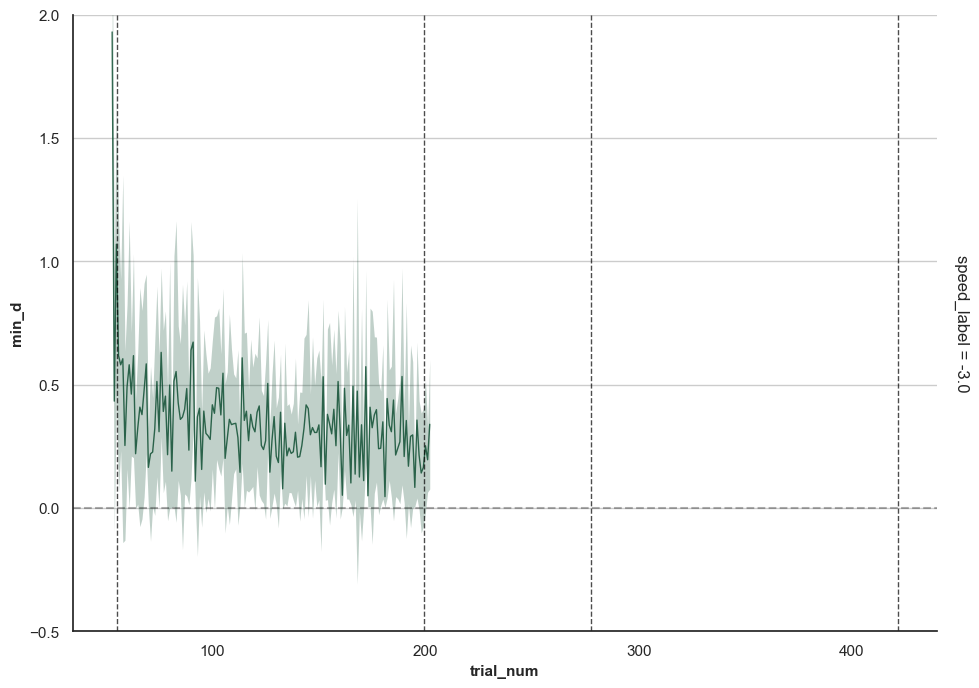

In [373]:
from src.plotting import plot_all_trials

plot_all_trials(df_participant, 
                     col_col =None,
                     row_col='speed_label',
                     cond_col=None,
                     ppid_col='ppid_full',
                     target_col='target_x_label',
                     y_col = 'min_d', # 
                     x_col='trial_num',
                     vertical_list=[55.5,199.5, 277.5,421.5],
                     hit_col='target_hit',
                     ref_range_col=None,
                     no_connect_col='phase',
                     context='notebook', 
                     transition_col='water_speed_binary',
                     marker_size=0,
                     estimator='mean',
                     y_lim=(-0.5,2),
                     show_zero_line=True
                    )                    